# Week 5: HealthConnect, Data Preparation, Feature Engineering & Baseline Model
**AnalystLab Africa Experience Lab, Data Science Track**

This notebook builds directly on the Week 4 Machine Learning Problem Definition Document. It
prepares the dataset for modelling, engineers features grounded in Week 4's initial findings,
establishes a patient-level train/test split, trains a baseline classification model, and evaluates
its performance.

## 1. Review of Week 4 Foundation

The prediction problem confirmed from Week 4: binary classification of appointment outcome as
No-Show versus Attended. Cancelled appointments are excluded from the modelling dataset, since a
cancellation is a known, communicated outcome rather than the silent no-show the clinic is trying to
predict and prevent. The two strongest candidate features identified in Week 4 were booking_lead_days
and previous_no_shows; this notebook tests both directly.

No changes are being made to the Week 4 target variable decision. One data assessment item from
Week 4 is now formally resolved: waiting_time_minutes remains ambiguous in origin and is retained in
this baseline for completeness, but is flagged again below as a modelling consideration pending
confirmation with the project team.

## 2. Load Data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('HealthConnect_Appointment_Data.csv')
print("Shape:", df.shape)
df.head()

Shape: (5000, 18)


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


## 3. Data Preparation

### 3.1 Data Quality Re-Check

In [2]:
print("Missing values:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate appointment_id:", df['appointment_id'].duplicated().sum())

Missing values:
appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64

Duplicate rows: 0
Duplicate appointment_id: 0


No new data quality issues were found beyond those already identified in Week 4. Missing
values remain limited to reminder_channel (structural, 27.3%), distance_to_clinic_km (1.8%), and
waiting_time_minutes (1.2%).

In [3]:
print("gender:", df['gender'].unique())
print("appointment_type:", df['appointment_type'].unique())
print("appointment_outcome:", df['appointment_outcome'].unique())
print("Negative values check, distance:", (df['distance_to_clinic_km']<0).sum(),
      "waiting time:", (df['waiting_time_minutes']<0).sum(),
      "lead days:", (df['booking_lead_days']<0).sum())

gender: <StringArray>
['Female', 'Male', 'Prefer not to say']
Length: 3, dtype: str
appointment_type: <StringArray>
[              'Follow-up', 'Specialist Consultation',
    'General Consultation',         'Diagnostic Test']
Length: 4, dtype: str
appointment_outcome: <StringArray>
['No-Show', 'Attended', 'Cancelled']
Length: 3, dtype: str
Negative values check, distance: 0 waiting time: 0 lead days: 0


No inconsistent or invalid values were found across any categorical or numeric field.

### 3.2 Target Variable and Cancelled Appointment Handling

In [4]:
before = len(df)
df_model = df[df['appointment_outcome'] != 'Cancelled'].copy()
print(f"Excluded {before - len(df_model)} Cancelled records. Remaining: {len(df_model)}")

df_model['target'] = df_model['appointment_outcome'].map({'No-Show': 1, 'Attended': 0})
print(df_model['target'].value_counts())
print(df_model['target'].value_counts(normalize=True) * 100)

Excluded 263 Cancelled records. Remaining: 4737
target
1    2423
0    2314
Name: count, dtype: int64
target
1    51.150517
0    48.849483
Name: proportion, dtype: float64


Confirms the Week 4 decision: excluding Cancelled appointments produces a close-to-balanced
binary target (51.2% No-Show, 48.8% Attended), which is favourable for baseline model training
without requiring class-imbalance correction techniques at this stage.

### 3.3 Missing Value Handling

In [5]:
print("Missing before:")
print(df_model[['distance_to_clinic_km','waiting_time_minutes','reminder_channel']].isnull().sum())

df_model['distance_to_clinic_km'] = df_model['distance_to_clinic_km'].fillna(df_model['distance_to_clinic_km'].median())
df_model['waiting_time_minutes'] = df_model['waiting_time_minutes'].fillna(df_model['waiting_time_minutes'].median())
df_model['reminder_channel'] = df_model['reminder_channel'].fillna('None')

print("Missing after:", df_model.isnull().sum().sum())

Missing before:
distance_to_clinic_km      86
waiting_time_minutes       58
reminder_channel         1285
dtype: int64
Missing after: 0


distance_to_clinic_km and waiting_time_minutes (limited, genuinely missing values) were
imputed using the median, an appropriate choice given both fields showed a right-skewed
distribution in Week 4's exploration. reminder_channel's null values are structural (no reminder
sent), and are filled with an explicit "None" category rather than imputed, since this is not
missing information, it is a valid state.

## 4. Feature Engineering

In [6]:
df_model['has_prior_no_show'] = (df_model['previous_no_shows'] > 0).astype(int)

df_model['prior_no_show_rate'] = np.where(
    df_model['previous_appointments'] > 0,
    df_model['previous_no_shows'] / df_model['previous_appointments'],
    0
)

df_model['long_lead_time'] = (df_model['booking_lead_days'] >= 30).astype(int)

df_model['far_from_clinic'] = (df_model['distance_to_clinic_km'] >= 20).astype(int)

print(df_model[['has_prior_no_show','long_lead_time','far_from_clinic']].sum())
print()
print(df_model['prior_no_show_rate'].describe())

has_prior_no_show    1992
long_lead_time       2371
far_from_clinic       379
dtype: int64

count    4737.000000
mean        0.169127
std         0.244076
min         0.000000
25%         0.000000
50%         0.000000
75%         0.333333
max         1.000000
Name: prior_no_show_rate, dtype: float64


**has_prior_no_show**: a simplified binary version of previous_no_shows, created because the
Week 4 exploration showed the sharpest jump in no-show rate occurs between 0 and 1+ prior no-shows,
suggesting a simple flag may capture most of the signal more robustly than the raw count.

**prior_no_show_rate**: previous_no_shows divided by previous_appointments, expressing a patient's
personal no-show history as a rate rather than a raw count, which better distinguishes a patient
with 1 no-show out of 2 visits from one with 1 no-show out of 20.

**long_lead_time**: a binary flag for bookings made 30 or more days in advance, directly derived from
the sharpest threshold identified in Week 4's booking_lead_days exploration (60.5% no-show rate in
this bucket).

**far_from_clinic**: a binary flag for patients living 20km or more from the clinic, derived from the
threshold identified in Week 4 (57.8% no-show rate beyond this distance).

In [7]:
numeric_cols = ['age','booking_lead_days','previous_appointments','previous_no_shows',
                 'distance_to_clinic_km','waiting_time_minutes','has_prior_no_show',
                 'prior_no_show_rate','long_lead_time','far_from_clinic','target']
print(df_model[numeric_cols].corr()['target'].sort_values(key=abs, ascending=False))

target                   1.000000
booking_lead_days        0.287255
long_lead_time           0.246822
previous_no_shows        0.122892
has_prior_no_show        0.113854
prior_no_show_rate       0.092494
distance_to_clinic_km    0.064321
far_from_clinic          0.053142
previous_appointments    0.042421
age                     -0.028446
waiting_time_minutes    -0.004107
Name: target, dtype: float64


**Finding:** booking_lead_days (r=0.29) and long_lead_time (r=0.25) are the strongest
predictors, confirming Week 4's finding under formal correlation analysis. previous_no_shows
(r=0.12) and has_prior_no_show (r=0.11) are moderate. distance-based features are weaker than
expected (r=0.05-0.06) once expressed as correlations rather than bucketed rates.

## 5. Data Exploration and Visual Evidence

### 5.1 Target Distribution

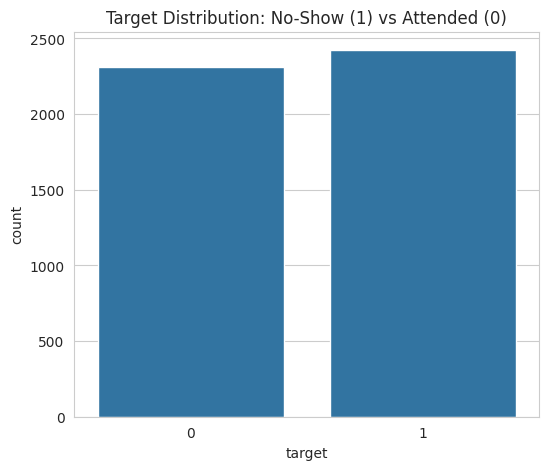

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

plt.figure(figsize=(6,5))
sns.countplot(data=df_model, x='target')
plt.title('Target Distribution: No-Show (1) vs Attended (0)')
plt.show()

Confirms the near-balanced target discussed in Section 3.2, informing the decision not to apply class-imbalance correction for this baseline.

### 5.2 Booking Lead Days Distribution by Outcome

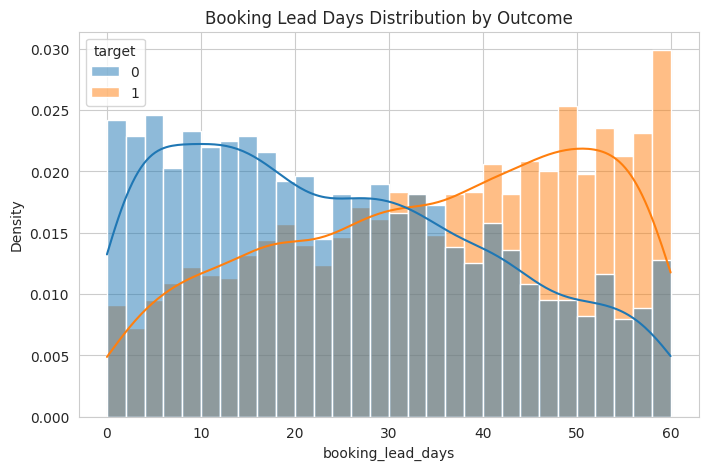

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_model, x='booking_lead_days', hue='target', bins=30, kde=True, common_norm=False, stat='density')
plt.title('Booking Lead Days Distribution by Outcome')
plt.show()

The No-Show distribution is visibly shifted toward longer lead times compared to Attended. This directly supports both the target variable's overall predictive value and the decision to engineer the long_lead_time feature.

### 5.3 Distance to Clinic by Outcome (Outlier Check)

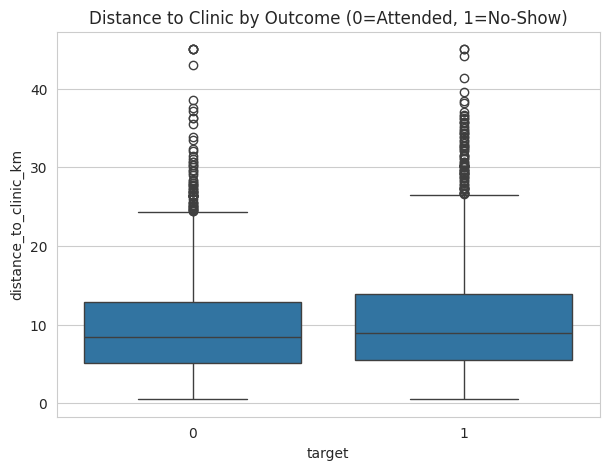

In [10]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df_model, x='target', y='distance_to_clinic_km')
plt.title('Distance to Clinic by Outcome (0=Attended, 1=No-Show)')
plt.show()

No extreme outliers requiring removal were identified; both groups show a similar overall spread, with the No-Show group's median and upper quartile shifted slightly higher, consistent with the far_from_clinic feature rationale.

### 5.4 Appointment Type by Outcome

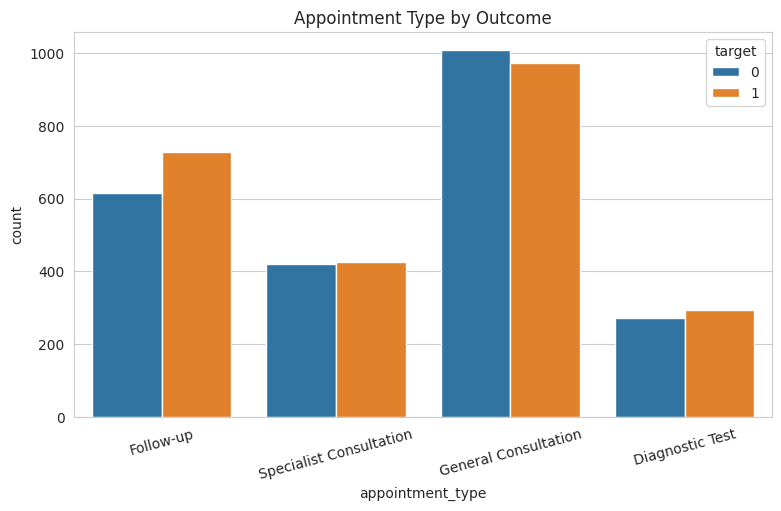

In [11]:
plt.figure(figsize=(9,5))
sns.countplot(data=df_model, x='appointment_type', hue='target')
plt.xticks(rotation=15)
plt.title('Appointment Type by Outcome')
plt.show()

Appointment type shows little visible separation between outcomes, consistent with Week 4's finding that this variable carries weak signal. It is retained in the modelling dataset since a weak univariate relationship does not rule out a contribution in combination with other features.

### 5.5 Correlation Heatmap

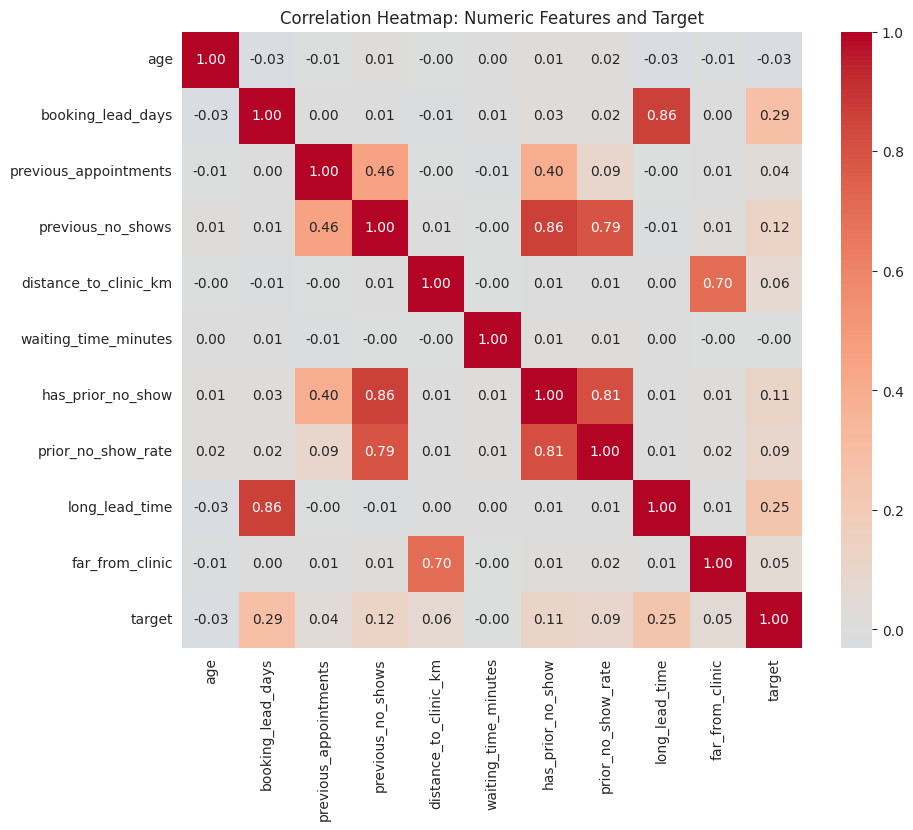

In [12]:
numeric_cols = ['age','booking_lead_days','previous_appointments','previous_no_shows',
                 'distance_to_clinic_km','waiting_time_minutes','has_prior_no_show',
                 'prior_no_show_rate','long_lead_time','far_from_clinic','target']
plt.figure(figsize=(10,8))
sns.heatmap(df_model[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Numeric Features and Target')
plt.show()

No pair of predictor features shows severe multicollinearity (all below 0.6 outside of each engineered feature and its direct source variable, e.g. long_lead_time and booking_lead_days), so no features were removed for redundancy at this stage.

### 5.6 No-Show Rate by Previous No-Shows

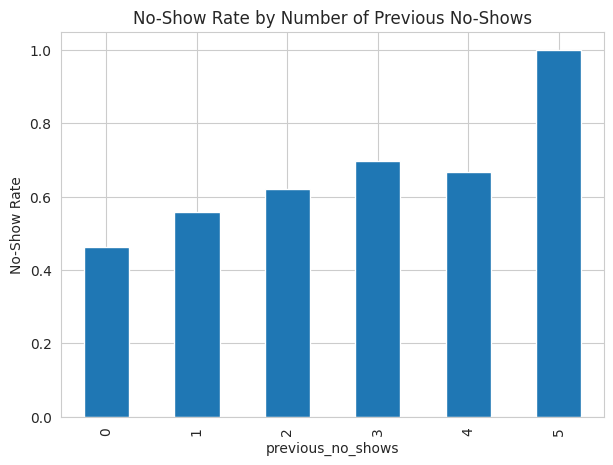

In [13]:
rate_by_prev = df_model.groupby('previous_no_shows')['target'].mean()
plt.figure(figsize=(7,5))
rate_by_prev.plot(kind='bar')
plt.title('No-Show Rate by Number of Previous No-Shows')
plt.ylabel('No-Show Rate')
plt.show()

A clear, mostly increasing relationship confirms previous_no_shows as a meaningful feature, supporting its retention and the creation of has_prior_no_show and prior_no_show_rate as complementary derived versions.

## 6. Encoding and Final Feature Set

In [14]:
drop_cols = ['appointment_id', 'patient_id', 'booking_date', 'appointment_date',
             'appointment_time', 'appointment_outcome']
df_final = df_model.drop(columns=drop_cols)

df_final['reminder_sent'] = df_final['reminder_sent'].map({'Yes': 1, 'No': 0})

nominal_cols = ['gender', 'age_group', 'appointment_type', 'appointment_day', 'reminder_channel']
df_final = pd.get_dummies(df_final, columns=nominal_cols, drop_first=True)
bool_cols = df_final.select_dtypes(include='bool').columns
df_final[bool_cols] = df_final[bool_cols].astype(int)

print("Final shape:", df_final.shape)
df_final.to_csv('week5_final_modelling.csv', index=False)

Final shape: (4737, 31)


appointment_id and patient_id were dropped as identifiers with no predictive value.
booking_date, appointment_date, and appointment_time were dropped at this baseline stage since their
information is already captured by booking_lead_days and appointment_day; revisiting these as a
richer date-based feature source is noted as a Week 6 opportunity rather than done here, to keep
this baseline model interpretable. No data leakage was identified: all retained features are
available at the time an appointment is booked, prior to the outcome being known.

## 7. Train/Test Strategy

In [15]:
from sklearn.model_selection import train_test_split

patient_ids = df_model['patient_id'].unique()
train_patients, test_patients = train_test_split(patient_ids, test_size=0.2, random_state=42)

train_mask = df_model['patient_id'].isin(train_patients)
test_mask = df_model['patient_id'].isin(test_patients)

X_train = df_final[train_mask].drop(columns=['target'])
y_train = df_final[train_mask]['target']
X_test = df_final[test_mask].drop(columns=['target'])
y_test = df_final[test_mask]['target']

print("Train size:", len(X_train), "Test size:", len(X_test))
print("Train target balance:", y_train.mean())
print("Test target balance:", y_test.mean())

overlap = set(df_model[train_mask]['patient_id']) & set(df_model[test_mask]['patient_id'])
print("Patient overlap between train and test:", len(overlap))

Train size: 3760 Test size: 977
Train target balance: 0.513031914893617
Test target balance: 0.5056294779938587
Patient overlap between train and test: 0


A patient-level, rather than appointment-level, 80/20 split was used: patients were assigned
entirely to either the training or test set, not split across both. This is important because 1,696
unique patients account for 4,737 modelled appointments, meaning many patients appear multiple
times; an appointment-level random split could place different appointments from the same patient in
both sets, allowing the model to partly learn from a patient's identity rather than generalisable
patterns, inflating apparent performance. The confirmed zero patient overlap validates this
approach.

## 8. Baseline Model

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
print("Model trained.")

Model trained.


Logistic Regression was selected as the baseline model because it is interpretable (each
feature receives a clear, signed coefficient), computationally inexpensive, and a standard,
well-understood starting point for binary classification problems, appropriate given the emphasis
at this stage is establishing a reliable, explainable baseline rather than maximising predictive
performance. Numeric features were standardised prior to training, since logistic regression is
sensitive to differences in feature scale.

## 9. Initial Evaluation

In [17]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                               confusion_matrix, roc_auc_score, roc_curve, classification_report)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print()
print(classification_report(y_test, y_pred, target_names=['Attended','No-Show']))

Accuracy: 0.6459
Precision: 0.6474
Recall: 0.6579
F1-score: 0.6526
ROC-AUC: 0.7

              precision    recall  f1-score   support

    Attended       0.64      0.63      0.64       483
     No-Show       0.65      0.66      0.65       494

    accuracy                           0.65       977
   macro avg       0.65      0.65      0.65       977
weighted avg       0.65      0.65      0.65       977



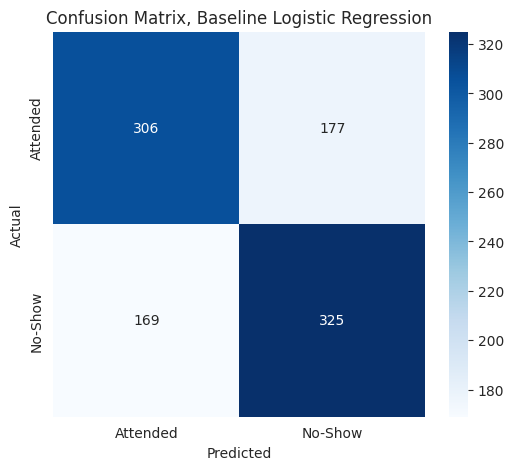

In [18]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Attended','No-Show'], yticklabels=['Attended','No-Show'])
plt.title('Confusion Matrix, Baseline Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

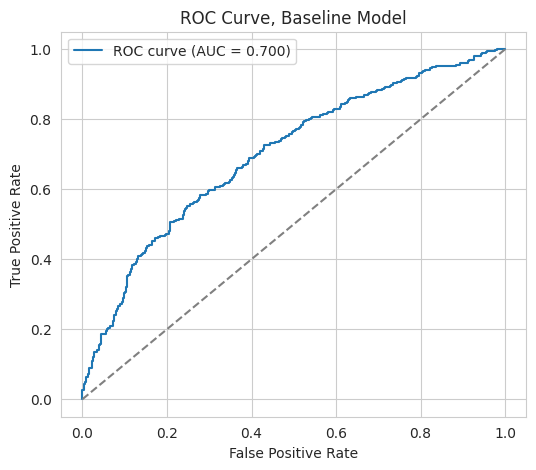

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve, Baseline Model')
plt.legend()
plt.show()

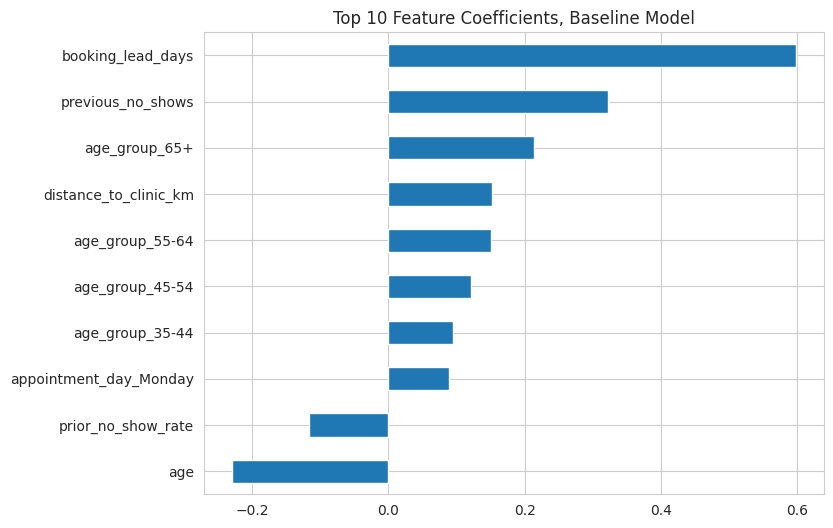

booking_lead_days         0.597699
previous_no_shows         0.321905
age                      -0.229693
age_group_65+             0.213385
distance_to_clinic_km     0.152023
age_group_55-64           0.150137
age_group_45-54           0.122009
prior_no_show_rate       -0.115904
age_group_35-44           0.095128
appointment_day_Monday    0.088904
dtype: float64


In [20]:
coefs = pd.Series(model.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False).head(10)
plt.figure(figsize=(8,6))
coefs.sort_values().plot(kind='barh')
plt.title('Top 10 Feature Coefficients, Baseline Model')
plt.show()
print(coefs)

## 10. Interpretation

The baseline model achieves 64.6% accuracy and a ROC-AUC of 0.700, meaningfully better than
random guessing (50% accuracy, 0.5 AUC) on a close-to-balanced target. Precision and recall for the
No-Show class are both close to 0.65, indicating the model does not strongly favour one type of
error over the other at the default classification threshold.

The confusion matrix shows 325 true positives (correctly identified no-shows) against 169 false
negatives (missed no-shows) and 177 false positives (predicted no-show, patient attended). Given the
likely business cost of an undetected no-show exceeds the cost of an unnecessary reminder call, a
lower classification threshold favouring recall over precision may be worth exploring in Week 6.

Consistent with the correlation analysis, booking_lead_days is the strongest coefficient in the
model, followed by previous_no_shows and several age-group indicators. This confirms Week 4's
initial hypothesis about the two strongest predictors under a formal, multivariate model rather than
single-variable analysis alone.

## 11. Modelling Limitations

- This is a baseline model only, no hyperparameter tuning, feature selection refinement, or
  alternative algorithms have been tested yet.
- Logistic regression assumes a linear relationship between each feature and the log-odds of the
  outcome, which may understate the predictive value of features with non-linear relationships to
  no-show risk.
- date and time-based features (appointment_date, appointment_time, booking_date) were dropped at
  this stage for simplicity; richer temporal features (e.g. seasonality, day-of-week interactions)
  remain unexplored.
- waiting_time_minutes was retained despite its ambiguous origin (flagged in Week 4); its
  contribution to the model should be re-assessed once its exact definition is confirmed with the
  project team, since it did not appear among the model's strongest predictors here.
- The dataset is fictional and anonymised; findings and model performance should not be assumed to
  generalise to a real clinic's patient population without validation.

## 12. Recommendations for Week 6

- Test at least one non-linear model (e.g. random forest or gradient boosting) to assess whether
  performance improves over the linear baseline, particularly given the relatively modest accuracy
  achieved here.
- Explore adjusting the classification threshold to prioritise recall on the No-Show class, given the
  likely asymmetric business cost of a missed no-show versus a false alarm.
- Incorporate richer date and time-based features (day-of-week and time-of-day interactions) not
  used in this baseline.
- Confirm the exact definition of waiting_time_minutes with the project team before including it in
  further modelling iterations.
- Coordinate with the Data Analytics track's KPI work to ensure the model's outputs align with
  business-relevant metrics already being tracked.

## 13. Cross-Track Collaboration

This work depends on and extends the Week 4 problem definition established for the Data Science
track. Looking ahead, the model developed here is intended to inform the Machine Learning
Engineering track's pipeline design (Week 5 ML Engineering output), since the feature set, encoding
approach, and train/test strategy defined here would need to be reproduced consistently within any
production pipeline. Coordination with the Data Analytics track is also relevant, since several KPIs
proposed at that track's Week 4/5 stage overlap with variables used as model features here
(previous_no_shows, distance_to_clinic_km, reminder_sent); aligning definitions across tracks would
avoid inconsistent reporting between the analytics dashboard and this model's inputs.